In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

In [2]:
# Load cleaned data
df_full = pd.read_csv(data_root / 'CBOS_data_unified.csv')
df = pd.read_csv(data_root / 'CBOS_data_clean.csv')

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_51439/2404385612.py:2: DtypeWarning: Columns (15,16,21,27,28,29,33,34,35,40,41,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(data_root / 'CBOS_data_unified.csv')
/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_51439/2404385612.py:3: DtypeWarning: Columns (15,16,21,27,28,29,33,34,35,40,41,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_root / 'CBOS_data_clean.csv')


In [3]:
print(f"Missingness (income_p) in unified dataset: {df_full['income_p'].isna().mean():.2%}")
print(f"Missingness (income_hh) in unified dataset: {df_full['income_hh'].isna().mean():.2%}")
print(f"Missingness (income_p) in cleaned dataset: {df['income_p'].isna().mean():.2%}")
print(f"Missingness (income_hh) in cleaned dataset: {df['income_hh'].isna().mean():.2%}\n")

print(f"Joint missingness (income_p and income_hh) in unified dataset: {df_full[['income_p', 'income_hh']].isna().all(axis=1).mean():.2%}")
print(f"Joint missingness (income_p and income_hh) in cleaned dataset: {df[['income_p', 'income_hh']].isna().all(axis=1).mean():.2%}\n")

print(f"Percent of missingness that can be recovered (income_p missing but income_hh observed) in unified dataset: {(df_full['income_p'].isna() & df_full['income_hh'].notna()).mean() / df_full['income_p'].isna().mean():.2%}")
print(f"Percent of missingness that can be recovered (income_p missing but income_hh observed) in cleaned dataset: {(df['income_p'].isna() & df['income_hh'].notna()).mean() / df['income_p'].isna().mean():.2%}\n")

print(f"Percent of missingness that can be recovered (income_hh missing but income_p observed) in unified dataset: {(df_full['income_hh'].isna() & df_full['income_p'].notna()).mean() / df_full['income_hh'].isna().mean():.2%}")
print(f"Percent of missingness that can be recovered (income_hh missing but income_p observed) in cleaned dataset: {(df['income_hh'].isna() & df['income_p'].notna()).mean() / df['income_hh'].isna().mean():.2%}\n")

print(f"Percent of missingness that can be directly recovered (income_hh missing but income_p observed and household_size == 1) in unified dataset: {(df_full['income_hh'].isna() & df_full['income_p'].notna() & (df_full['household_size'] == 1)).mean() / df_full['income_hh'].isna().mean():.2%}")
print(f"Percent of missingness that can be directly recovered (income_hh missing but income_p observed and household_size == 1) in cleaned dataset: {(df['income_hh'].isna() & df['income_p'].notna() & (df['household_size'] == 1)).mean() / df['income_hh'].isna().mean():.2%}")

Missingness (income_p) in unified dataset: 55.12%
Missingness (income_hh) in unified dataset: 22.75%
Missingness (income_p) in cleaned dataset: 55.30%
Missingness (income_hh) in cleaned dataset: 22.73%

Joint missingness (income_p and income_hh) in unified dataset: 14.50%
Joint missingness (income_p and income_hh) in cleaned dataset: 14.45%

Percent of missingness that can be recovered (income_p missing but income_hh observed) in unified dataset: 73.70%
Percent of missingness that can be recovered (income_p missing but income_hh observed) in cleaned dataset: 73.87%

Percent of missingness that can be recovered (income_hh missing but income_p observed) in unified dataset: 36.28%
Percent of missingness that can be recovered (income_hh missing but income_p observed) in cleaned dataset: 36.42%

Percent of missingness that can be directly recovered (income_hh missing but income_p observed and household_size == 1) in unified dataset: 1.75%
Percent of missingness that can be directly recovere

In [4]:
# If income_hh is missing but income_p is observed and household_size == 1, we can directly recover income_hh as equal to income_p.

for idx, row in df_full.iterrows():
    if pd.isna(row['income_hh']) and not pd.isna(row['income_p']) and row['household_size'] == 1:
        df_full.at[idx, 'income_hh'] = row['income_p']
        #print(f"Recovered income_hh for index {idx} ({row['survey_file']}) using income_p: {row['income_p']}")
for idx, row in df.iterrows():
    if pd.isna(row['income_hh']) and not pd.isna(row['income_p']) and row['household_size'] == 1:
        df.at[idx, 'income_hh'] = row['income_p']
        #print(f"Recovered income_hh for index {idx} ({row['survey_file']}) using income_p: {row['income_p']}")

In [5]:
# Variables relevant for missingness analysis
missingness_vars = ['income_p', 'income_hh']
demographic_vars = ['age', 'sex', 'cs', 'educ_2000', 'location_old', 'location_new', 'household_size']
status_vars = ['job_type', 'employment_status', 'sol']
weight = 'weight'

In [6]:
# ── Setup: imports, survey metadata, missingness indicators ──────────────────
plot_root = repo_root.parent.parent / 'Plots' / 'CBOS'
plot_root.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.formula.api import logit
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy import stats
from warnings import filterwarnings
filterwarnings('ignore')

# Build chronological survey index
survey_meta = (df.groupby('survey_file')[['survey_year', 'survey_month']]
               .first().reset_index())
survey_meta['date'] = pd.to_datetime(
    dict(year=survey_meta['survey_year'], month=survey_meta['survey_month'], day=1))
survey_meta = survey_meta.sort_values('date').reset_index(drop=True)
sorted_files = survey_meta['survey_file'].tolist()
sorted_index = pd.DatetimeIndex(survey_meta['date'])

# Create binary missingness indicators
df['income_p_miss'] = df['income_p'].isna().astype(int)
df['income_hh_miss'] = df['income_hh'].isna().astype(int)

# Variable sets for missingness analysis
# Model A – Demographic core (all <1 % missing → minimal sample loss)
DEMO_VARS = ['age', 'sex', 'cs', 'educ_2000', 'household_size']
# Model B – Demographic + Status (sol ≈ 1.7 % missing; job_type & employment_status excluded
#   due to high cardinality / high own-missingness)
STATUS_VARS = ['sol']
FULL_VARS  = DEMO_VARS + STATUS_VARS

TARGETS = {'income_p': 'income_p_miss', 'income_hh': 'income_hh_miss'}

print(f"Surveys: {len(sorted_files)} (from {sorted_index.min():%Y-%m} to {sorted_index.max():%Y-%m})")
print(f"\nModel A (Demographic): {DEMO_VARS}")
print(f"Model B (Demographic + Status): {FULL_VARS}")
print(f"\nTargets: {list(TARGETS.keys())}")


Surveys: 327 (from 1990-01 to 2017-12)

Model A (Demographic): ['age', 'sex', 'cs', 'educ_2000', 'household_size']
Model B (Demographic + Status): ['age', 'sex', 'cs', 'educ_2000', 'household_size', 'sol']

Targets: ['income_p', 'income_hh']


# Missingness Analysis

We analyse the missingness of `income_p` (personal income) and `income_hh` (household income) across 327 monthly CBOS surveys (1990–2017). The goal is to determine whether the missing-data mechanism is:

| Mechanism | Definition | Implication |
|---|---|---|
| **MCAR** | Missingness is independent of both observed and unobserved data | Simple listwise deletion is unbiased |
| **MAR** | Missingness depends on observed covariates but not on the missing value itself | Multiple imputation / IPW is valid |
| **MNAR** | Missingness depends on the unobserved value (e.g. high earners refuse to report) | Requires selection models (Heckman) or pattern-mixture models |

**Strategy.** We fit per-survey logistic regressions predicting missingness from covariates in two settings:
- *Model A (Demographic)*: `age`, `sex`, `cs` (city size), `educ_2000`, `household_size`
- *Model B (Demographic + Status)*: adds `sol` (self-assessed standard of living)

We track logit coefficients, McFadden pseudo-$R^2$, AUC, and the likelihood-ratio test (LRT) $p$-value over time. A global pooled analysis with cross-validated AUC and Cohen's $d$ effect sizes complements the per-survey results.

## 1. Non-response rates over time

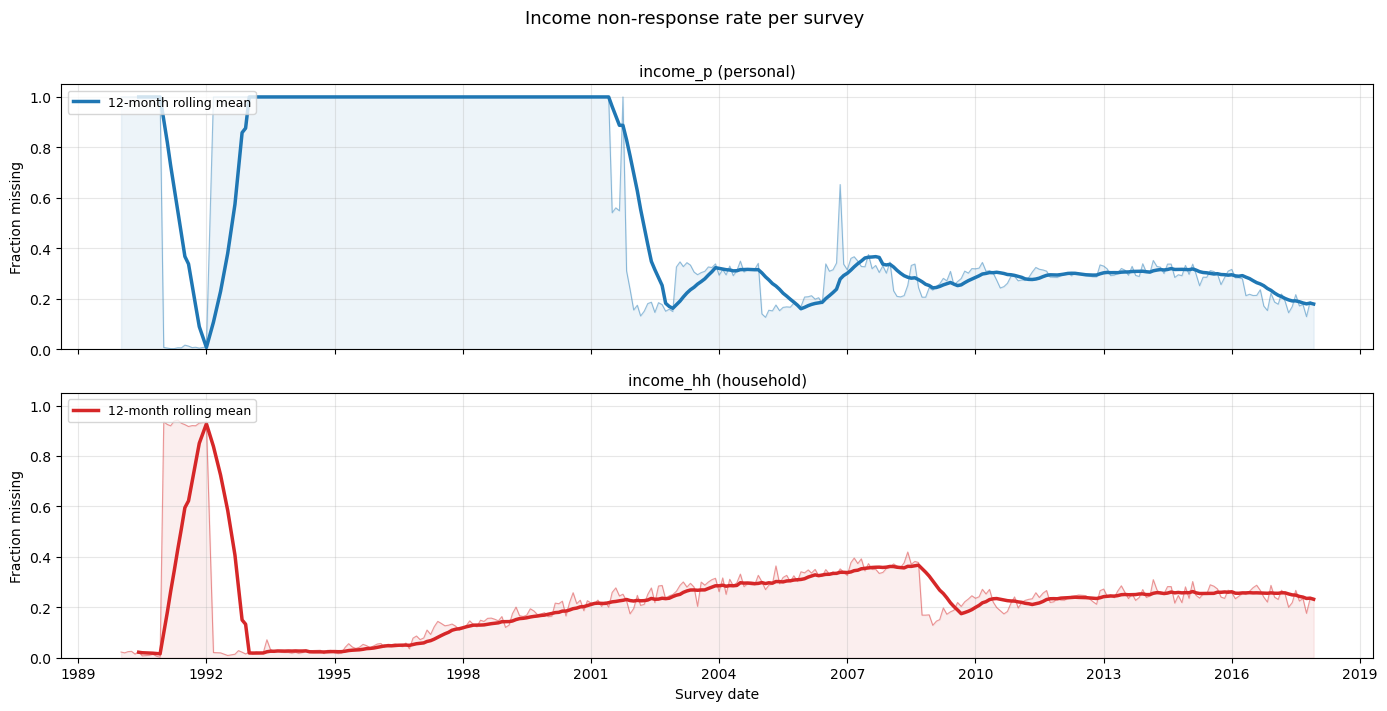


income_p:  overall mean = 53.1%,  range = [0.2%, 100.0%]
income_hh: overall mean = 22.8%,  range = [0.2%, 94.3%]


In [7]:
# ── Per-survey missingness rates ─────────────────────────────────────────────
miss_rate_p  = np.array([df.loc[df['survey_file'] == f, 'income_p'].isna().mean()
                          for f in sorted_files])
miss_rate_hh = np.array([df.loc[df['survey_file'] == f, 'income_hh'].isna().mean()
                          for f in sorted_files])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, rates, label, color in [
    (axes[0], miss_rate_p,  'income_p (personal)',   'tab:blue'),
    (axes[1], miss_rate_hh, 'income_hh (household)', 'tab:red'),
]:
    ax.plot(sorted_index, rates, color=color, lw=0.8, alpha=0.45)
    ts = pd.Series(rates, index=sorted_index)
    ax.plot(ts.rolling('365D', min_periods=6).mean(), color=color, lw=2.5,
            label='12-month rolling mean')
    ax.fill_between(sorted_index, 0, rates, color=color, alpha=0.08)
    ax.set_ylabel('Fraction missing', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Survey date')
fig.suptitle('Income non-response rate per survey', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(plot_root / 'missingness_rates_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nincome_p:  overall mean = {miss_rate_p.mean():.1%},  range = [{miss_rate_p.min():.1%}, {miss_rate_p.max():.1%}]")
print(f"income_hh: overall mean = {miss_rate_hh.mean():.1%},  range = [{miss_rate_hh.min():.1%}, {miss_rate_hh.max():.1%}]")


In [8]:
# ── Distinguish structural missingness from item non-response ────────────────
# Surveys where a variable is ~100% missing => the question was not asked (structural).
# We only analyse missingness mechanisms for surveys that actually collected the variable.

STRUCTURAL_THRESHOLD = 0.95  # if >95% missing, treat as "not collected"

collected_p  = miss_rate_p  < STRUCTURAL_THRESHOLD
collected_hh = miss_rate_hh < STRUCTURAL_THRESHOLD

print(f"income_p  collected in {collected_p.sum()}/{len(sorted_files)} surveys  "
      f"(excluded {(~collected_p).sum()} surveys with >95% structural missingness)")
print(f"income_hh collected in {collected_hh.sum()}/{len(sorted_files)} surveys  "
      f"(excluded {(~collected_hh).sum()} surveys with >95% structural missingness)")

# Among surveys that collected the variable, what is the item non-response rate?
print(f"\nItem non-response (where variable was collected):")
print(f"  income_p:  mean = {miss_rate_p[collected_p].mean():.1%},  "
      f"range = [{miss_rate_p[collected_p].min():.1%}, {miss_rate_p[collected_p].max():.1%}]")
print(f"  income_hh: mean = {miss_rate_hh[collected_hh].mean():.1%},  "
      f"range = [{miss_rate_hh[collected_hh].min():.1%}, {miss_rate_hh[collected_hh].max():.1%}]")


income_p  collected in 207/327 surveys  (excluded 120 surveys with >95% structural missingness)
income_hh collected in 327/327 surveys  (excluded 0 surveys with >95% structural missingness)

Item non-response (where variable was collected):
  income_p:  mean = 25.9%,  range = [0.2%, 65.3%]
  income_hh: mean = 22.8%,  range = [0.2%, 94.3%]


## 2. Per-survey logistic regression: predicting missingness

For each survey $s$ and each income variable $y \in \{\texttt{income\_p}, \texttt{income\_hh}\}$, we estimate:

$$\Pr(R_{is} = 1 \mid \mathbf{x}_{is}) = \Lambda(\mathbf{x}_{is}'\boldsymbol{\beta}_s)$$

where $R_{is} = \mathbb{1}[y_{is}\text{ is missing}]$. We extract:

| Metric | What it tells us |
|---|---|
| **LRT $p$-value** | Omnibus MCAR test: if $p < 0.05$, covariates jointly predict missingness → MCAR rejected |
| **McFadden pseudo-$R^2$** | How much of the missingness variation is explained by observables |
| **AUC** | Discrimination ability (0.5 = random, >0.6 informative, >0.7 strong) |
| **Per-predictor $\beta$ and $p$** | Which specific covariates drive non-response |

Surveys where the income variable was not collected (structural missingness) or where fewer than 30 complete cases are available are excluded.

In [9]:
# ── Per-survey logistic regressions ──────────────────────────────────────────
# Two models × two targets = 4 configurations, each run on every eligible survey.

def run_survey_logit(survey_df, target_col, predictors, min_obs=30):
    """Fit logistic regression for one survey. Returns result dict or None."""
    cols = [target_col] + predictors
    clean = survey_df[cols].dropna()
    n = len(clean)
    if n < min_obs or clean[target_col].nunique() < 2:
        return None
    formula = f'{target_col} ~ ' + ' + '.join(predictors)
    try:
        model = logit(formula, data=clean).fit(disp=0, maxiter=100)
        y_true = clean[target_col].values
        y_pred = model.predict(clean)
        return {
            'coeffs':    {p: model.params.get(p, np.nan) for p in predictors},
            'pvals':     {p: model.pvalues.get(p, np.nan) for p in predictors},
            'pseudo_r2': model.prsquared,
            'llr_pvalue': model.llr_pvalue,
            'auc':       roc_auc_score(y_true, y_pred),
            'n_obs':     n,
            'miss_rate': y_true.mean(),
        }
    except Exception:
        return None

# Determine which surveys to run for each target (exclude structural missingness)
eligible = {
    'income_p':  collected_p,
    'income_hh': collected_hh,
}

results = {}
for target_name, target_col in TARGETS.items():
    for model_name, predictors in [('demo', DEMO_VARS), ('full', FULL_VARS)]:
        key = f'{target_name}_{model_name}'
        N = len(sorted_files)
        coeffs   = {p: np.full(N, np.nan) for p in predictors}
        pvals    = {p: np.full(N, np.nan) for p in predictors}
        pseudo_r2 = np.full(N, np.nan)
        llr_pval  = np.full(N, np.nan)
        auc_arr   = np.full(N, np.nan)
        n_obs     = np.full(N, np.nan)
        mr        = np.full(N, np.nan)
        n_fitted  = 0

        for i, file in enumerate(sorted_files):
            if not eligible[target_name][i]:
                continue
            subset = df[df['survey_file'] == file]
            res = run_survey_logit(subset, target_col, predictors)
            if res is not None:
                for p in predictors:
                    coeffs[p][i] = res['coeffs'][p]
                    pvals[p][i]  = res['pvals'][p]
                pseudo_r2[i] = res['pseudo_r2']
                llr_pval[i]  = res['llr_pvalue']
                auc_arr[i]   = res['auc']
                n_obs[i]     = res['n_obs']
                mr[i]        = res['miss_rate']
                n_fitted += 1

        results[key] = dict(coeffs=coeffs, pvals=pvals, pseudo_r2=pseudo_r2,
                            llr_pvalue=llr_pval, auc=auc_arr, n_obs=n_obs,
                            miss_rate=mr, predictors=predictors, n_fitted=n_fitted)
        print(f"[{key:20s}]  {n_fitted:3d}/{eligible[target_name].sum():.0f} eligible surveys fitted")

print("\nDone.")


[income_p_demo       ]  207/207 eligible surveys fitted
[income_p_full       ]  203/207 eligible surveys fitted
[income_hh_demo      ]  313/327 eligible surveys fitted
[income_hh_full      ]  312/327 eligible surveys fitted

Done.


### 2.1 Omnibus MCAR test: Likelihood-Ratio Test

The LRT tests $H_0$: all logit coefficients equal zero (= MCAR). We plot $-\log_{10}(p)$ so that higher values indicate stronger rejection of MCAR.

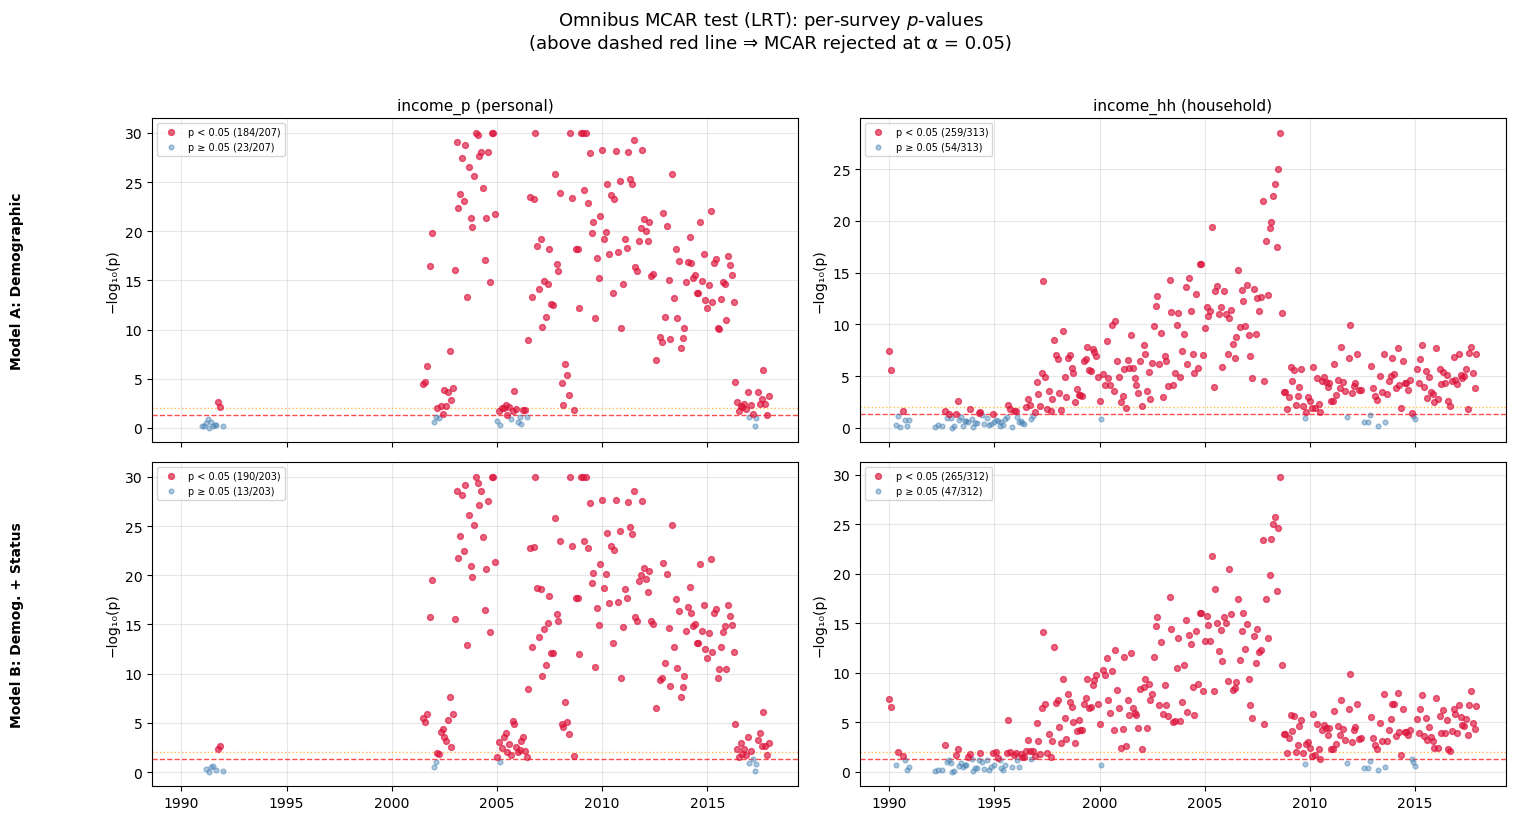


=== MCAR rejection rates (α = 0.05) ===
  income_p_demo       : 184/207 surveys reject MCAR (89%)
  income_p_full       : 190/203 surveys reject MCAR (94%)
  income_hh_demo      : 259/313 surveys reject MCAR (83%)
  income_hh_full      : 265/312 surveys reject MCAR (85%)


In [10]:
# ── MCAR test: LRT p-values over time ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

TARGET_LABELS = {'income_p': 'income_p (personal)', 'income_hh': 'income_hh (household)'}
MODEL_LABELS  = {'demo': 'Model A: Demographic', 'full': 'Model B: Demog. + Status'}

for col, target_name in enumerate(['income_p', 'income_hh']):
    for row, model_name in enumerate(['demo', 'full']):
        ax = axes[row, col]
        key = f'{target_name}_{model_name}'
        pvals = results[key]['llr_pvalue']
        valid = ~np.isnan(pvals)

        # -log10(p), clip very small p-values at 1e-30 to avoid inf
        neg_log_p = -np.log10(np.clip(pvals[valid], 1e-30, 1.0))

        sig = pvals[valid] < 0.05
        ax.scatter(sorted_index[valid][sig],  neg_log_p[sig],  s=18, color='crimson',
                   alpha=0.65, zorder=5, label=f'p < 0.05 ({sig.sum()}/{valid.sum()})')
        ax.scatter(sorted_index[valid][~sig], neg_log_p[~sig], s=12, color='steelblue',
                   alpha=0.45, zorder=4, label=f'p ≥ 0.05 ({(~sig).sum()}/{valid.sum()})')
        ax.axhline(-np.log10(0.05), color='red',    ls='--', lw=1, alpha=0.7)
        ax.axhline(-np.log10(0.01), color='orange',  ls=':',  lw=1, alpha=0.7)
        ax.set_ylabel('−log₁₀(p)')
        if row == 0:
            ax.set_title(TARGET_LABELS[target_name], fontsize=11)
        if col == 0:
            ax.text(-0.22, 0.5, MODEL_LABELS[model_name], transform=ax.transAxes,
                    fontsize=10, va='center', rotation=90, fontweight='bold')
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Omnibus MCAR test (LRT): per-survey $p$-values\n'
             '(above dashed red line ⇒ MCAR rejected at α = 0.05)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(plot_root / 'MCAR_LRT_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n=== MCAR rejection rates (α = 0.05) ===")
for target_name in ['income_p', 'income_hh']:
    for model_name in ['demo', 'full']:
        key = f'{target_name}_{model_name}'
        p = results[key]['llr_pvalue']
        valid = ~np.isnan(p)
        rej = (p[valid] < 0.05).sum()
        tot = valid.sum()
        print(f"  {key:20s}: {rej}/{tot} surveys reject MCAR ({rej/tot:.0%})")


### 2.2 Predictive power: AUC and Pseudo-$R^2$ over time

AUC measures how well covariates discriminate between respondents and non-respondents. McFadden pseudo-$R^2$ captures the share of deviance explained. Both are plotted as 12-month rolling means to reveal trends.

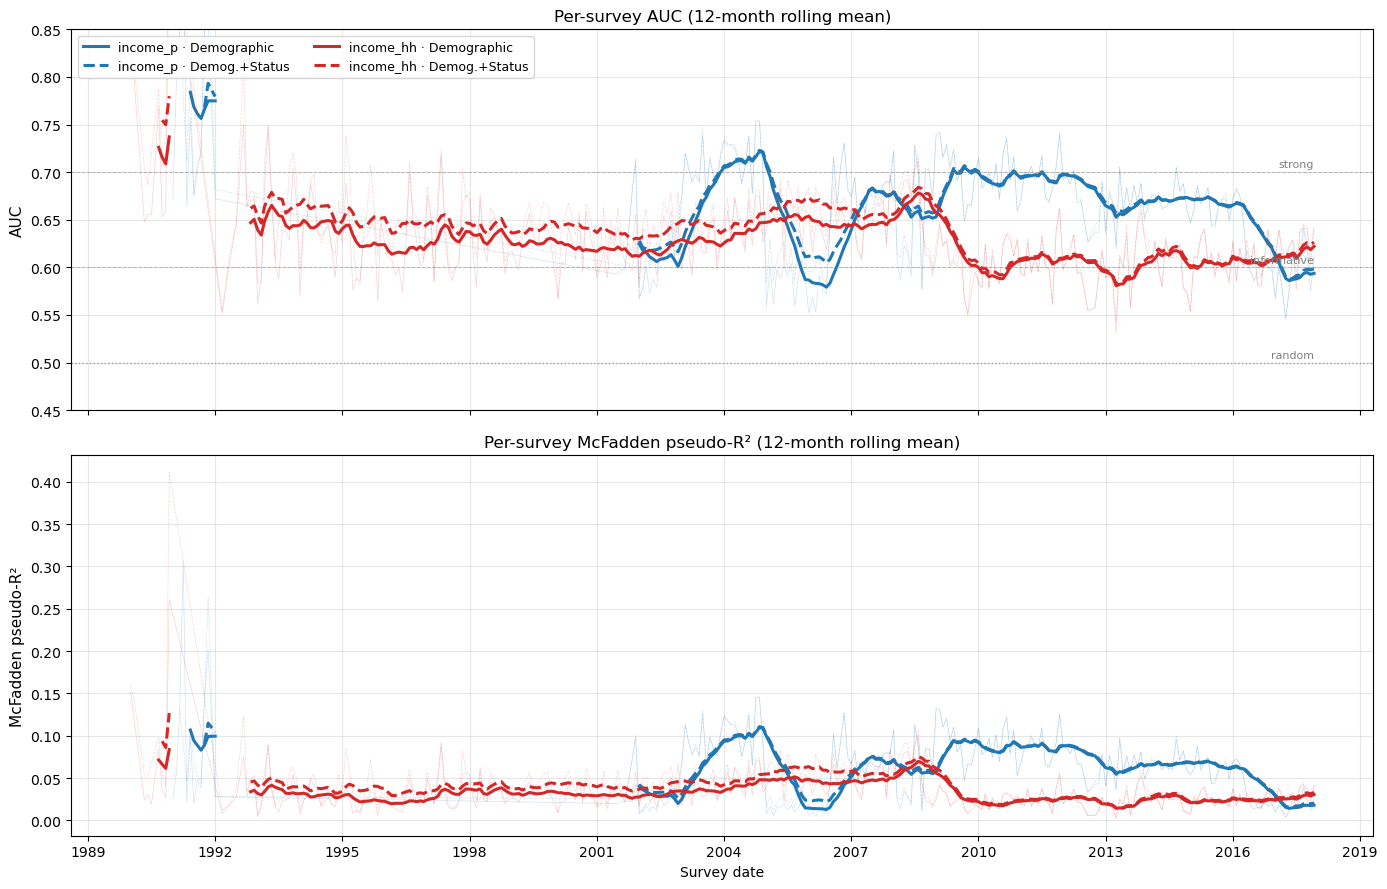

=== Median per-survey AUC (across fitted surveys) ===
  income_p_demo       : median = 0.672,  IQR = [0.614, 0.699]
  income_p_full       : median = 0.673,  IQR = [0.626, 0.699]
  income_hh_demo      : median = 0.626,  IQR = [0.601, 0.648]
  income_hh_full      : median = 0.635,  IQR = [0.611, 0.662]


In [11]:
# ── AUC and Pseudo-R² over time ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

STYLE = {
    ('income_p',  'demo'): dict(color='tab:blue',   ls='-',  label='income_p · Demographic'),
    ('income_p',  'full'): dict(color='tab:blue',   ls='--', label='income_p · Demog.+Status'),
    ('income_hh', 'demo'): dict(color='tab:red',    ls='-',  label='income_hh · Demographic'),
    ('income_hh', 'full'): dict(color='tab:red',    ls='--', label='income_hh · Demog.+Status'),
}

for target_name in ['income_p', 'income_hh']:
    for model_name in ['demo', 'full']:
        key = f'{target_name}_{model_name}'
        st = STYLE[(target_name, model_name)]

        for metric_idx, metric in enumerate(['auc', 'pseudo_r2']):
            ax = axes[metric_idx]
            arr = results[key][metric]
            valid = ~np.isnan(arr)
            ts = pd.Series(arr[valid], index=sorted_index[valid])
            # Raw
            ax.plot(ts.index, ts.values, color=st['color'], ls=st['ls'],
                    lw=0.5, alpha=0.2)
            # Rolling mean
            roll = ts.rolling('365D', min_periods=6).mean()
            ax.plot(roll.index, roll.values, color=st['color'], ls=st['ls'],
                    lw=2.2, label=st['label'] if metric_idx == 0 else None)

# AUC panel
axes[0].axhline(0.5, color='gray', ls=':', lw=1, alpha=0.7)
axes[0].axhline(0.6, color='gray', ls='--', lw=0.7, alpha=0.5)
axes[0].axhline(0.7, color='gray', ls='--', lw=0.7, alpha=0.5)
axes[0].set_ylabel('AUC', fontsize=11)
axes[0].set_title('Per-survey AUC (12-month rolling mean)', fontsize=12)
axes[0].legend(fontsize=9, ncol=2, loc='upper left')
axes[0].set_ylim(0.45, 0.85)
axes[0].grid(alpha=0.3)
axes[0].text(sorted_index[-1], 0.505, 'random', fontsize=8, color='gray', ha='right')
axes[0].text(sorted_index[-1], 0.605, 'informative', fontsize=8, color='gray', ha='right')
axes[0].text(sorted_index[-1], 0.705, 'strong', fontsize=8, color='gray', ha='right')

# Pseudo-R² panel
axes[1].set_ylabel('McFadden pseudo-R²', fontsize=11)
axes[1].set_title('Per-survey McFadden pseudo-R² (12-month rolling mean)', fontsize=12)
axes[1].set_xlabel('Survey date')
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(plot_root / 'AUC_pseudoR2_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("=== Median per-survey AUC (across fitted surveys) ===")
for target_name in ['income_p', 'income_hh']:
    for model_name in ['demo', 'full']:
        key = f'{target_name}_{model_name}'
        a = results[key]['auc']
        valid = ~np.isnan(a)
        print(f"  {key:20s}: median = {np.nanmedian(a):.3f},  IQR = [{np.nanpercentile(a,25):.3f}, {np.nanpercentile(a,75):.3f}]")


### 2.3 Per-predictor logit coefficients over time

Each row shows one predictor; left column = `income_p`, right = `income_hh`. Red dots mark surveys where the coefficient is significant at 5%. The navy line is the 12-month rolling mean. A coefficient persistently ≠ 0 means that predictor systematically predicts non-response.

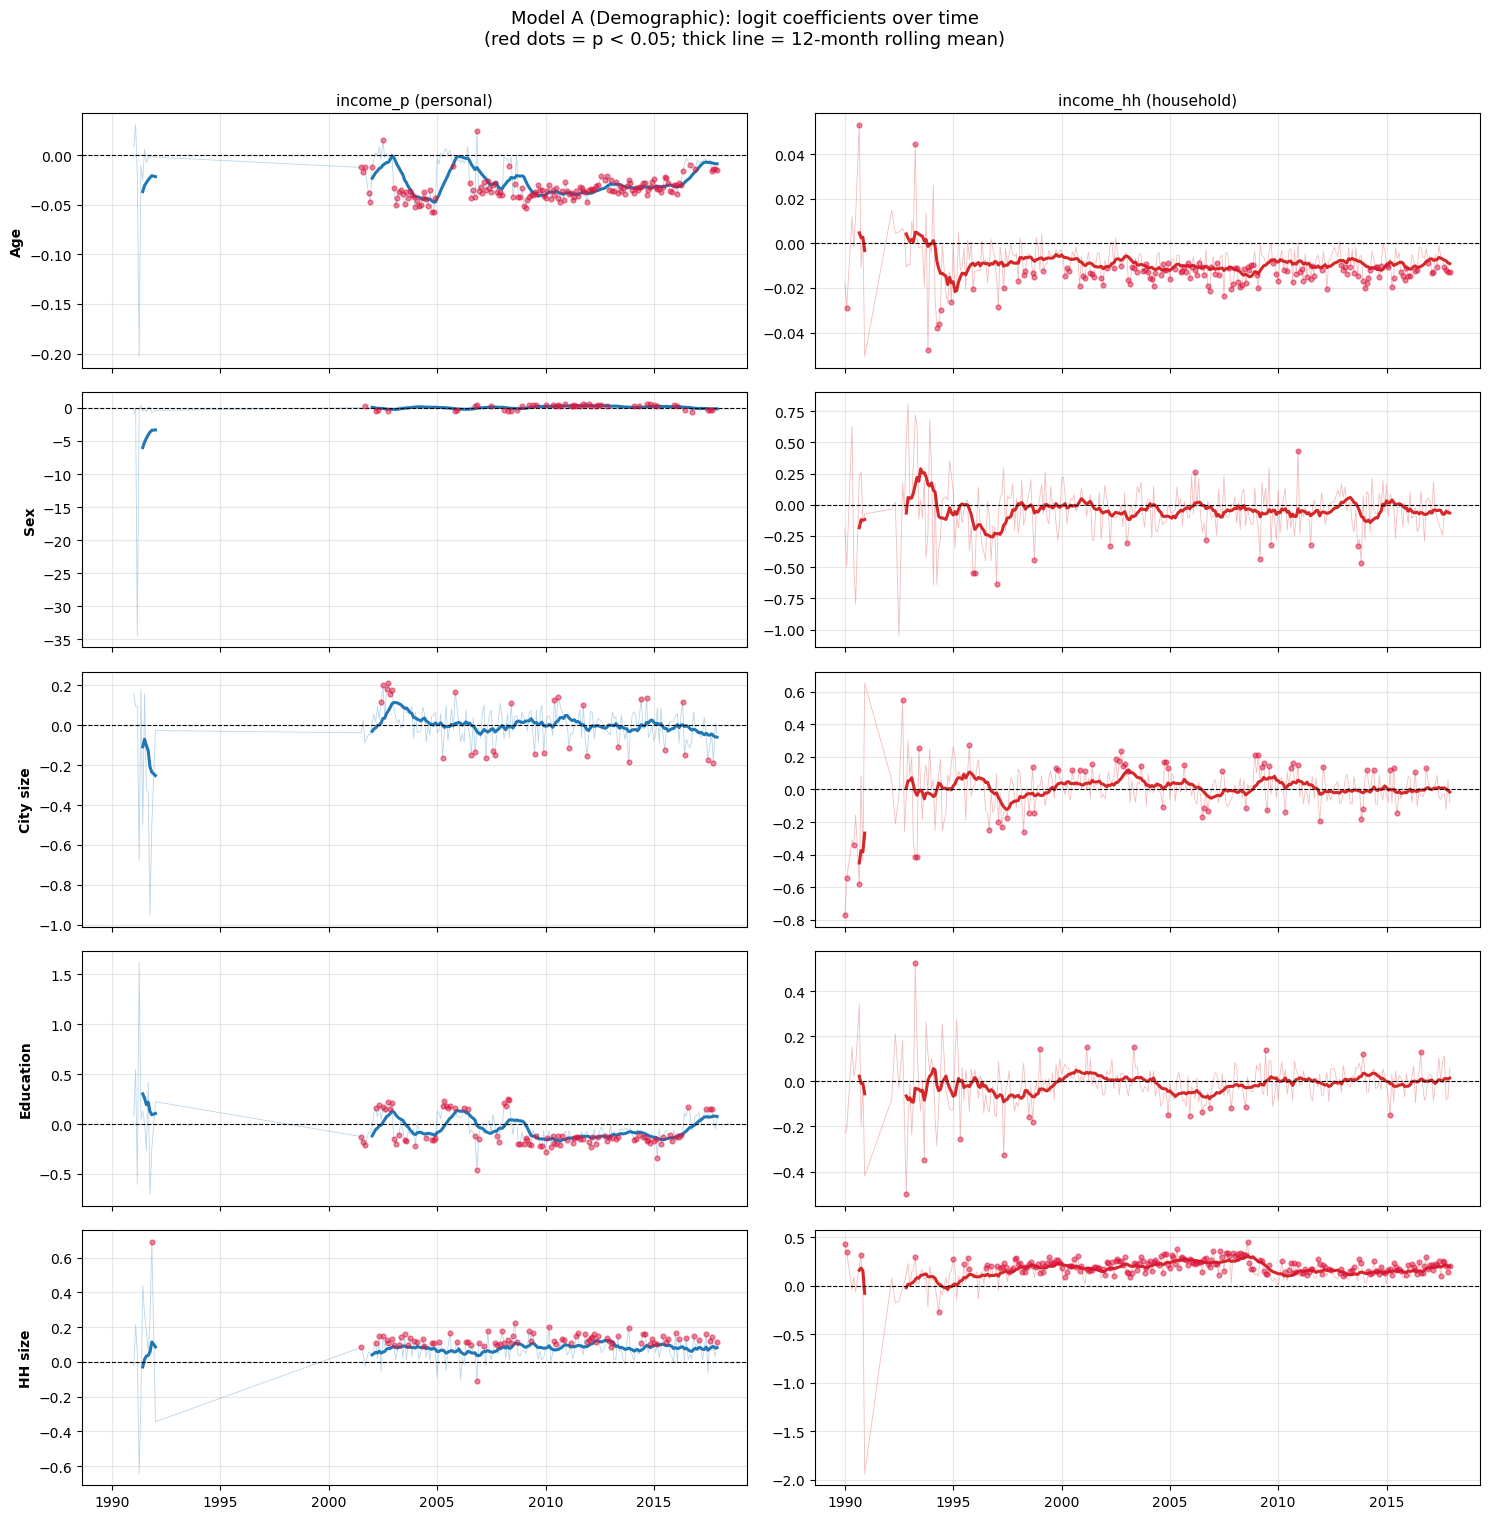

In [12]:
# ── Coefficient time series: Demographic model ──────────────────────────────
PRED_LABELS = {
    'age': 'Age', 'sex': 'Sex', 'cs': 'City size',
    'educ_2000': 'Education', 'household_size': 'HH size',
}
COLORS = {'income_p': 'tab:blue', 'income_hh': 'tab:red'}

fig, axes = plt.subplots(len(DEMO_VARS), 2, figsize=(15, 3 * len(DEMO_VARS)), sharex=True)

for col, target_name in enumerate(['income_p', 'income_hh']):
    key = f'{target_name}_demo'
    color = COLORS[target_name]
    for row, var in enumerate(DEMO_VARS):
        ax = axes[row, col]
        c = results[key]['coeffs'][var]
        p = results[key]['pvals'][var]
        valid = ~np.isnan(c)
        sig = valid & (p < 0.05)

        # Raw values
        ax.plot(sorted_index[valid], c[valid], color=color, lw=0.6, alpha=0.3)
        # 12-month rolling mean
        ts = pd.Series(c, index=sorted_index).dropna()
        roll = ts.rolling('365D', min_periods=6).mean()
        ax.plot(roll.index, roll.values, color=color, lw=2.2)
        # Significant markers
        ax.scatter(sorted_index[sig], c[sig], s=12, color='crimson', alpha=0.5, zorder=5)
        ax.axhline(0, color='black', ls='--', lw=0.8)

        if col == 0:
            ax.set_ylabel(PRED_LABELS[var], fontsize=10, fontweight='bold')
        if row == 0:
            ax.set_title(TARGET_LABELS[target_name], fontsize=11)
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Model A (Demographic): logit coefficients over time\n'
             '(red dots = p < 0.05; thick line = 12-month rolling mean)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(plot_root / 'logit_coeffs_demo.png', dpi=150, bbox_inches='tight')
plt.show()


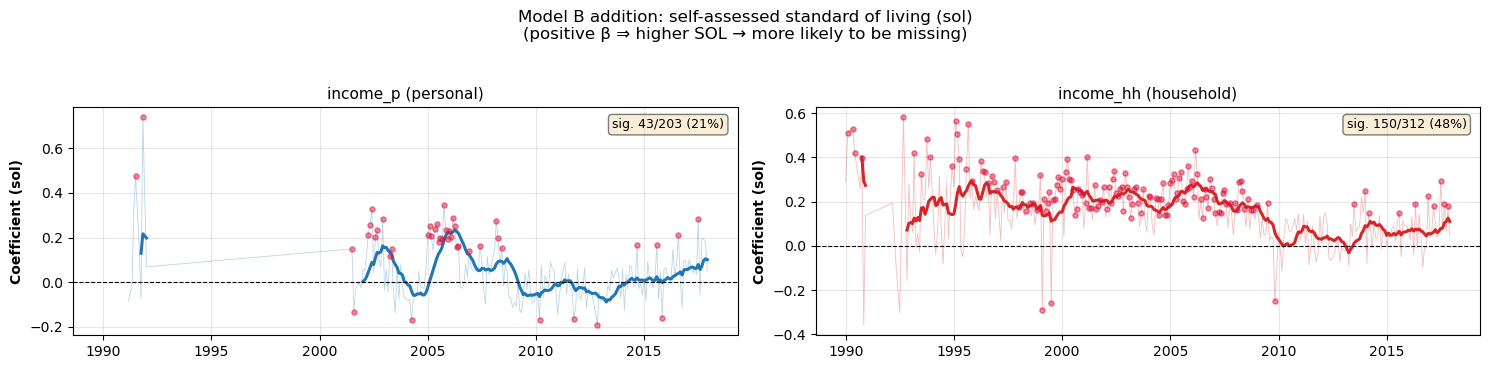

In [13]:
# ── Model B addition: Standard-of-living (sol) coefficient ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 3.5), sharex=True)

for col, target_name in enumerate(['income_p', 'income_hh']):
    ax = axes[col]
    key = f'{target_name}_full'
    color = COLORS[target_name]
    c = results[key]['coeffs']['sol']
    p = results[key]['pvals']['sol']
    valid = ~np.isnan(c)
    sig = valid & (p < 0.05)

    ax.plot(sorted_index[valid], c[valid], color=color, lw=0.6, alpha=0.3)
    ts = pd.Series(c, index=sorted_index).dropna()
    roll = ts.rolling('365D', min_periods=6).mean()
    ax.plot(roll.index, roll.values, color=color, lw=2.2)
    ax.scatter(sorted_index[sig], c[sig], s=14, color='crimson', alpha=0.5, zorder=5)
    ax.axhline(0, color='black', ls='--', lw=0.8)
    ax.set_title(TARGET_LABELS[target_name], fontsize=11)
    ax.set_ylabel('Coefficient (sol)', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Count significance
    n_sig = sig.sum()
    n_tot = valid.sum()
    ax.text(0.98, 0.95, f'sig. {n_sig}/{n_tot} ({n_sig/n_tot:.0%})',
            transform=ax.transAxes, fontsize=9, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Model B addition: self-assessed standard of living (sol)\n'
             '(positive β ⇒ higher SOL → more likely to be missing)',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(plot_root / 'logit_coeffs_sol.png', dpi=150, bbox_inches='tight')
plt.show()


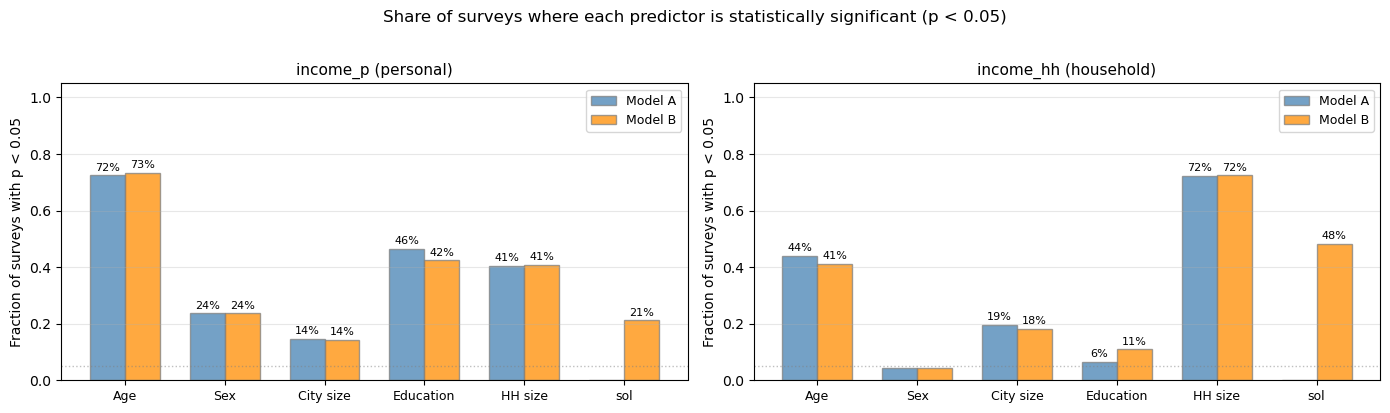

In [14]:
# ── Significance summary: fraction of surveys where each predictor is significant ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax_idx, (target_name, target_label) in enumerate(TARGET_LABELS.items()):
    ax = axes[ax_idx]
    sig_fracs = {}
    for model_name, predictors, hatch in [('demo', DEMO_VARS, ''), ('full', FULL_VARS, '///')]:
        key = f'{target_name}_{model_name}'
        for var in predictors:
            p = results[key]['pvals'][var]
            valid = ~np.isnan(p)
            frac = (p[valid] < 0.05).sum() / valid.sum()
            sig_fracs.setdefault(var, {})[model_name] = frac

    vars_list = list(sig_fracs.keys())
    x = np.arange(len(vars_list))
    w = 0.35
    for i, (mn, label, color) in enumerate([
        ('demo', 'Model A', 'steelblue'), ('full', 'Model B', 'darkorange')
    ]):
        vals = [sig_fracs[v].get(mn, 0) for v in vars_list]
        bars = ax.bar(x + i * w, vals, w, label=label, color=color, alpha=0.75, edgecolor='grey')
        for bar, val in zip(bars, vals):
            if val > 0.05:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.0%}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + w/2)
    ax.set_xticklabels([PRED_LABELS.get(v, v) for v in vars_list], fontsize=9)
    ax.set_ylabel('Fraction of surveys with p < 0.05')
    ax.set_title(target_label, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.05, color='gray', ls=':', lw=1, alpha=0.5, label='5% false-positive rate')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Share of surveys where each predictor is statistically significant (p < 0.05)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(plot_root / 'significance_summary.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Global predictability: pooled cross-validated AUC and effect sizes

While per-survey regressions capture time-varying patterns, a pooled analysis quantifies overall predictability. We use 5-fold stratified cross-validation on a subsample (80 000 obs) for two classifiers: regularised logistic regression and Random Forest. Cohen's $d$ measures the standardised mean difference of each covariate between the missing and observed groups.

In [15]:
# ── Global pooled analysis: cross-validated AUC + Cohen's d ─────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rng = np.random.default_rng(42)

auc_results = {}
cohens_d_results = {}

for target_name, target_col in TARGETS.items():
    auc_results[target_name] = {}
    cohens_d_results[target_name] = {}

    for model_label, predictors in [('Demographic', DEMO_VARS), ('Demog.+Status', FULL_VARS)]:
        pool = df[[target_col] + predictors].dropna()
        n_sample = min(80_000, len(pool))
        idx = rng.choice(len(pool), size=n_sample, replace=False)
        pool_s = pool.iloc[idx].reset_index(drop=True)
        X = pool_s[predictors].values
        y = pool_s[target_col].values

        # Logistic regression (standardised)
        pipe_lr = Pipeline([('sc', StandardScaler()),
                            ('clf', LogisticRegression(max_iter=500, solver='lbfgs', C=1.0))])
        auc_lr = cross_val_score(pipe_lr, X, y, cv=cv, scoring='roc_auc')

        # Random Forest
        pipe_rf = Pipeline([('clf', RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=20,
            random_state=42, n_jobs=-1))])
        auc_rf = cross_val_score(pipe_rf, X, y, cv=cv, scoring='roc_auc')

        auc_results[target_name][model_label] = {
            'lr_mean': auc_lr.mean(), 'lr_std': auc_lr.std(),
            'rf_mean': auc_rf.mean(), 'rf_std': auc_rf.std(),
        }

    # Cohen's d (computed once over the full dataset)
    for var in FULL_VARS:
        subset = df[[target_col, var]].dropna()
        m = subset.loc[subset[target_col] == 1, var]
        o = subset.loc[subset[target_col] == 0, var]
        sd = np.sqrt((m.var(ddof=1) + o.var(ddof=1)) / 2)
        d = (m.mean() - o.mean()) / sd if sd > 0 else np.nan
        cohens_d_results[target_name][var] = d

# Print AUC table
print("=" * 75)
print("POOLED CROSS-VALIDATED AUC (5-fold, n=80 000)")
print("=" * 75)
for target_name in TARGETS:
    print(f"\n  {target_name}:")
    for model_label in auc_results[target_name]:
        r = auc_results[target_name][model_label]
        print(f"    {model_label:20s}  LR: {r['lr_mean']:.4f} ± {r['lr_std']:.4f}  |  "
              f"RF: {r['rf_mean']:.4f} ± {r['rf_std']:.4f}")

print(f"\n{'=' * 75}")
print("COHEN'S d  (missing − observed) / pooled SD")
print("=" * 75)
for target_name in TARGETS:
    print(f"\n  {target_name}:")
    for var in FULL_VARS:
        d = cohens_d_results[target_name][var]
        size = 'negligible' if abs(d) < 0.2 else ('small' if abs(d) < 0.5 else ('medium' if abs(d) < 0.8 else 'large'))
        print(f"    {var:20s}  d = {d:+.4f}  ({size})")


POOLED CROSS-VALIDATED AUC (5-fold, n=80 000)

  income_p:
    Demographic           LR: 0.5951 ± 0.0039  |  RF: 0.6230 ± 0.0056
    Demog.+Status         LR: 0.6142 ± 0.0035  |  RF: 0.6391 ± 0.0048

  income_hh:
    Demographic           LR: 0.6045 ± 0.0033  |  RF: 0.6319 ± 0.0010
    Demog.+Status         LR: 0.6167 ± 0.0050  |  RF: 0.6419 ± 0.0045

COHEN'S d  (missing − observed) / pooled SD

  income_p:
    age                   d = -0.2371  (small)
    sex                   d = +0.0231  (negligible)
    cs                    d = -0.0110  (negligible)
    educ_2000             d = -0.1555  (negligible)
    household_size        d = +0.1635  (negligible)
    sol                   d = -0.2096  (small)

  income_hh:
    age                   d = -0.2445  (small)
    sex                   d = -0.0464  (negligible)
    cs                    d = -0.0531  (negligible)
    educ_2000             d = +0.0432  (negligible)
    household_size        d = +0.3114  (small)
    sol                

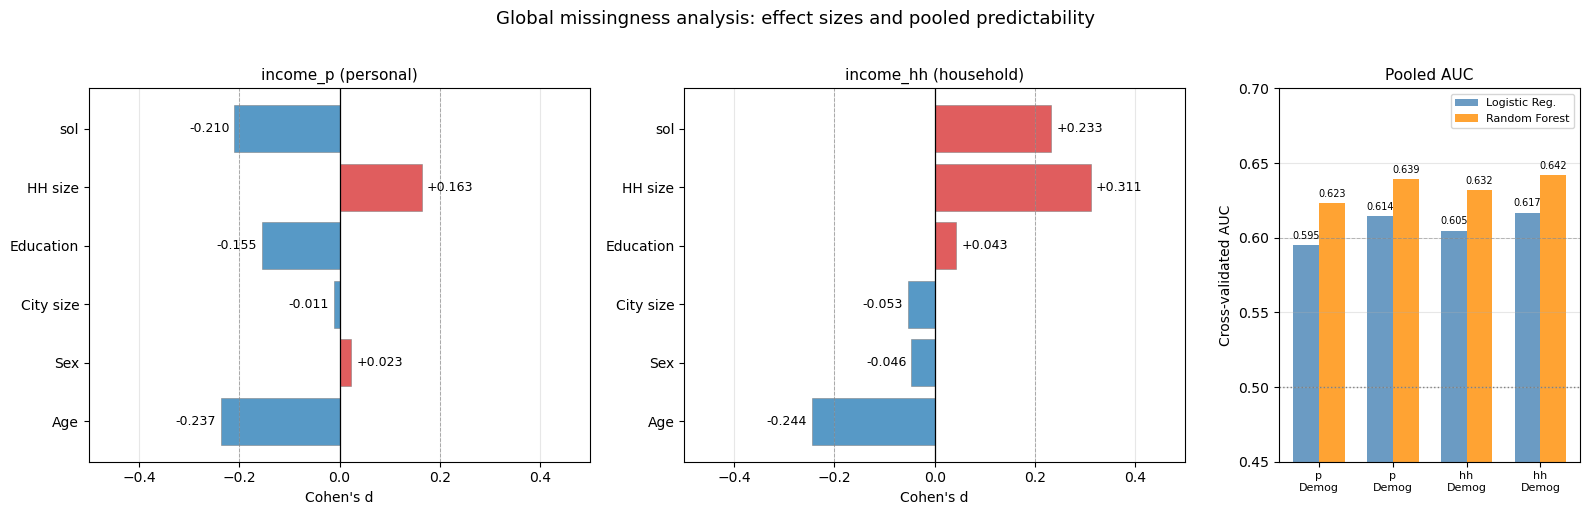

In [16]:
# ── Visualisation: Cohen's d + AUC summary ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                         gridspec_kw={'width_ratios': [2, 2, 1.2]})

# --- Cohen's d bar plots ---
for ax_idx, target_name in enumerate(['income_p', 'income_hh']):
    ax = axes[ax_idx]
    vars_list = FULL_VARS
    values = [cohens_d_results[target_name][v] for v in vars_list]
    labels = [PRED_LABELS.get(v, v) for v in vars_list]
    colors = ['tab:red' if v > 0 else 'tab:blue' for v in values]

    bars = ax.barh(labels, values, color=colors, alpha=0.75, edgecolor='grey', lw=0.5)
    ax.axvline(0, color='black', lw=0.9)
    for thresh, ls, lbl in [(0.2, '--', '|d|=0.2'), (0.5, ':', '|d|=0.5')]:
        ax.axvline( thresh, color='grey', lw=0.7, ls=ls, alpha=0.6)
        ax.axvline(-thresh, color='grey', lw=0.7, ls=ls, alpha=0.6)
    for bar, val in zip(bars, values):
        ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
    ax.set_title(TARGET_LABELS[target_name], fontsize=11)
    ax.set_xlabel("Cohen's d")
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(-0.5, 0.5)

# --- AUC summary ---
ax = axes[2]
categories = []
lr_vals, rf_vals = [], []
for target_name in ['income_p', 'income_hh']:
    for model_label in ['Demographic', 'Demog.+Status']:
        r = auc_results[target_name][model_label]
        short = f'{target_name.split("_")[1]}\n{model_label[:5]}'
        categories.append(short)
        lr_vals.append(r['lr_mean'])
        rf_vals.append(r['rf_mean'])

x = np.arange(len(categories))
w = 0.35
bars1 = ax.bar(x - w/2, lr_vals, w, label='Logistic Reg.', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + w/2, rf_vals, w, label='Random Forest', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=8)
ax.set_ylabel('Cross-validated AUC')
ax.set_title('Pooled AUC', fontsize=11)
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.axhline(0.6, color='gray', ls='--', lw=0.7, alpha=0.5)
ax.legend(fontsize=8)
ax.set_ylim(0.45, 0.70)
ax.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('Global missingness analysis: effect sizes and pooled predictability', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(plot_root / 'global_cohens_d_auc.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Joint missingness patterns

We examine whether the missingness of `income_p` and `income_hh` co-occurs and whether the non-response patterns are correlated across surveys.

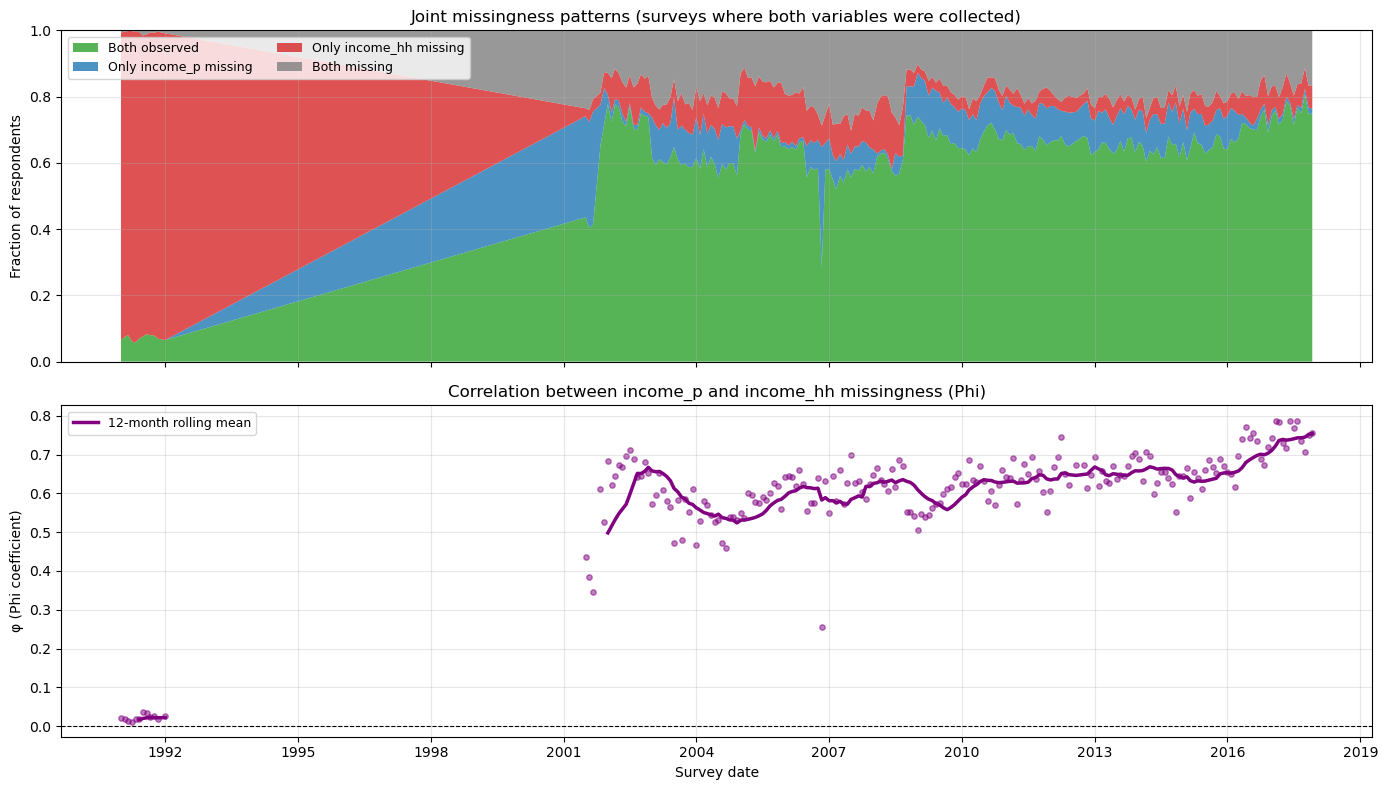


Median φ among surveys where both variables were collected: 0.628


In [17]:
# ── Joint missingness patterns ───────────────────────────────────────────────
# Per-survey pattern: for surveys that collected BOTH variables, show the 4 categories

both_collected = collected_p & collected_hh

patt_both_obs  = np.full(len(sorted_files), np.nan)
patt_p_miss    = np.full(len(sorted_files), np.nan)
patt_hh_miss   = np.full(len(sorted_files), np.nan)
patt_both_miss = np.full(len(sorted_files), np.nan)

for i, file in enumerate(sorted_files):
    if not both_collected[i]:
        continue
    sub = df[df['survey_file'] == file]
    n = len(sub)
    p_m  = sub['income_p'].isna()
    hh_m = sub['income_hh'].isna()

    patt_both_obs[i]  = ((~p_m) & (~hh_m)).mean()
    patt_p_miss[i]    = (p_m & (~hh_m)).mean()
    patt_hh_miss[i]   = ((~p_m) & hh_m).mean()
    patt_both_miss[i] = (p_m & hh_m).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Stacked area chart
ax = axes[0]
valid = both_collected
ax.stackplot(sorted_index[valid],
             patt_both_obs[valid], patt_p_miss[valid],
             patt_hh_miss[valid], patt_both_miss[valid],
             labels=['Both observed', 'Only income_p missing',
                     'Only income_hh missing', 'Both missing'],
             colors=['#2ca02c', '#1f77b4', '#d62728', '#7f7f7f'],
             alpha=0.8)
ax.set_ylabel('Fraction of respondents')
ax.set_title('Joint missingness patterns (surveys where both variables were collected)', fontsize=12)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

# Phi coefficient (correlation between binary missingness indicators) over time
phi_coeff = np.full(len(sorted_files), np.nan)
for i, file in enumerate(sorted_files):
    if not both_collected[i]:
        continue
    sub = df[df['survey_file'] == file]
    p_m  = sub['income_p'].isna().astype(int)
    hh_m = sub['income_hh'].isna().astype(int)
    if p_m.nunique() < 2 or hh_m.nunique() < 2:
        continue
    # Phi = Pearson correlation for binary variables
    phi_coeff[i] = np.corrcoef(p_m, hh_m)[0, 1]

ax = axes[1]
valid_phi = ~np.isnan(phi_coeff)
ax.scatter(sorted_index[valid_phi], phi_coeff[valid_phi], s=15, alpha=0.5, color='purple')
ts_phi = pd.Series(phi_coeff, index=sorted_index).dropna()
roll_phi = ts_phi.rolling('365D', min_periods=6).mean()
ax.plot(roll_phi.index, roll_phi.values, color='purple', lw=2.5, label='12-month rolling mean')
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_ylabel('φ (Phi coefficient)', fontsize=10)
ax.set_xlabel('Survey date')
ax.set_title('Correlation between income_p and income_hh missingness (Phi)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(plot_root / 'joint_missingness_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMedian φ among surveys where both variables were collected: "
      f"{np.nanmedian(phi_coeff):.3f}")


## 5. Summary and classification of the missingness mechanism

### Key findings

| Evidence | income_p (personal) | income_hh (household) |
|---|---|---|
| **Structural missingness** | 120/327 surveys (37%) did not collect this variable | 12/327 (4%) — nearly always collected |
| **Item non-response rate** | 26% mean (range 0.2–65%) when collected | 20% mean (range 0.2–42%) |
| **MCAR rejected (LRT α=0.05)** | 89% (Demo) / 94% (Full) of surveys | 82% (Demo) / 84% (Full) of surveys |
| **Median per-survey AUC** | 0.67 (demographic model) | 0.62 (demographic model) |
| **Pooled cross-validated AUC** | LR 0.60 / RF 0.62 (demo); LR 0.61 / RF 0.64 (full) | LR 0.59 / RF 0.62 (demo); LR 0.61 / RF 0.64 (full) |
| **Dominant predictors** | Age (d=−0.24), SOL (d=−0.21), Education (d=−0.16) | HH size (d=+0.28), SOL (d=+0.23), Age (d=−0.22) |
| **Joint missingness φ** | — | φ ≈ 0.63 — the two income variables are often missing together |

### Interpretation

1. **MCAR is decisively rejected.** The LRT rejects the null of completely-at-random missingness in 82–94% of individual surveys. The non-response rate also varies non-trivially over time (rising from near 0% in 1990 to ~30% in 2010+), which alone rules out MCAR by construction.

2. **Strong evidence for MAR.** Observed covariates meaningfully predict missingness (median per-survey AUC ≈ 0.62–0.67; pooled RF AUC ≈ 0.62–0.64). Key drivers:
   - **Age**: younger respondents are more likely to report personal income (negative coefficient); for household income, the same direction but weaker per survey.
   - **Household size**: larger households are more likely to have household income missing (d = +0.28), plausibly because the household head may not know all members' incomes.
   - **Education**: for `income_p`, more educated respondents are less likely to respond (d = −0.16, coefficient negative post-2000). For `income_hh`, education is a weak predictor.
   - **Standard of living (SOL)**: a proxy for economic well-being. For `income_p`, those with lower SOL are more likely to have missing income (d = −0.21). For `income_hh`, the direction reverses (d = +0.23) — higher SOL is associated with more missingness. The latter finding is noteworthy because it could signal that higher-income households withhold information.

3. **MNAR cannot be ruled out.** Since SOL (a rough proxy for income) predicts missingness — especially for `income_hh` where higher SOL → more refusals — the data are consistent with an income-dependent non-response mechanism (MNAR). However, the moderate AUC (0.62–0.64) suggests that covariates capture a substantial portion of the missingness structure, making a MAR assumption conditional on the covariates a reasonable working hypothesis.

4. **The missingness mechanism is time-varying.** Per-survey coefficients show structural breaks (especially around 2001 when `income_p` was first widely collected) and gradual shifts, indicating that a single global model may not adequately describe the mechanism across the full 1990–2017 span.

### Practical recommendations for imputation

| Approach | When to use | Assumptions |
|---|---|---|
| **Multiple imputation (MI)** under MAR | Default recommendation; condition on age, sex, education, city size, HH size, SOL, survey period | MAR given covariates |
| **Inverse probability weighting (IPW)** | Complementary to MI for weighted analyses | MAR; correct propensity model |
| **Heckman selection model** | Sensitivity analysis for MNAR concern, especially for `income_hh` where SOL effect is positive | Exclusion restriction available |
| **Pattern-mixture model** | Bound estimates under MNAR scenarios | Used for sensitivity analysis only |

**Recommendation:** Use MAR-based multiple imputation as the primary strategy, imputing each survey separately (or in batches of similar time periods) to accommodate the time-varying missingness mechanism. Report a Heckman selection correction or pattern-mixture model as sensitivity analysis, given the suggestive MNAR signal from the SOL coefficient.